In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import os

## 📑 Reading Dataset

In [3]:
df = pd.read_csv(f"{os.getcwd()}\\iris.csv")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## 🟢 Dataset Classes

In [4]:
np.unique(df["species"])

array(['setosa', 'versicolor', 'virginica'], dtype=object)

## 📍 EDA

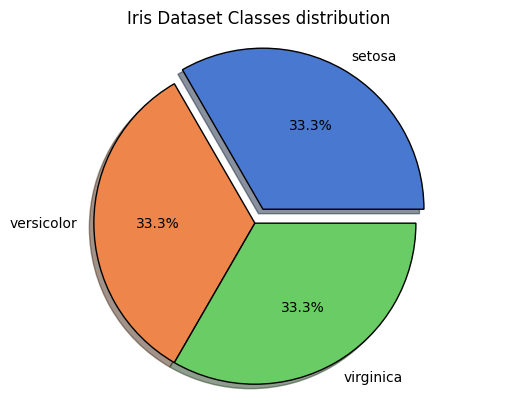

In [5]:
classes = df["species"].value_counts()
plt.pie(x=classes.values,labels=classes.keys(),wedgeprops = {'edgecolor': 'black'},autopct="%0.1f%%",shadow=True,colors=sns.color_palette("muted"),labeldistance=1.1,explode=[0.1,0,0])
plt.title("Iris Dataset Classes distribution")
plt.axis("equal")
plt.show()

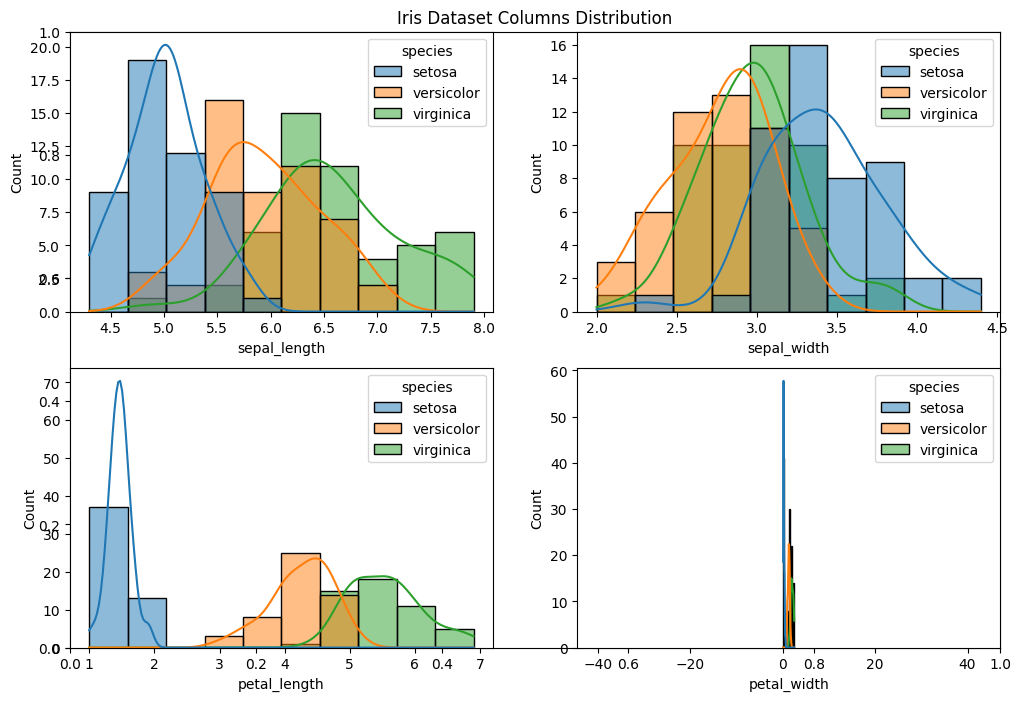

In [6]:
plt.figure(figsize=(12,8))
plt.title("Iris Dataset Columns Distribution")

for i, column in enumerate(df.columns[:-1],start=0):
    plt.subplot(2,2,i+1) 
    sns.histplot(data=df,x=df.columns[i],bins=10,hue=df.columns[-1],kde=True,fill=True)

plt.axis("equal")
plt.show()


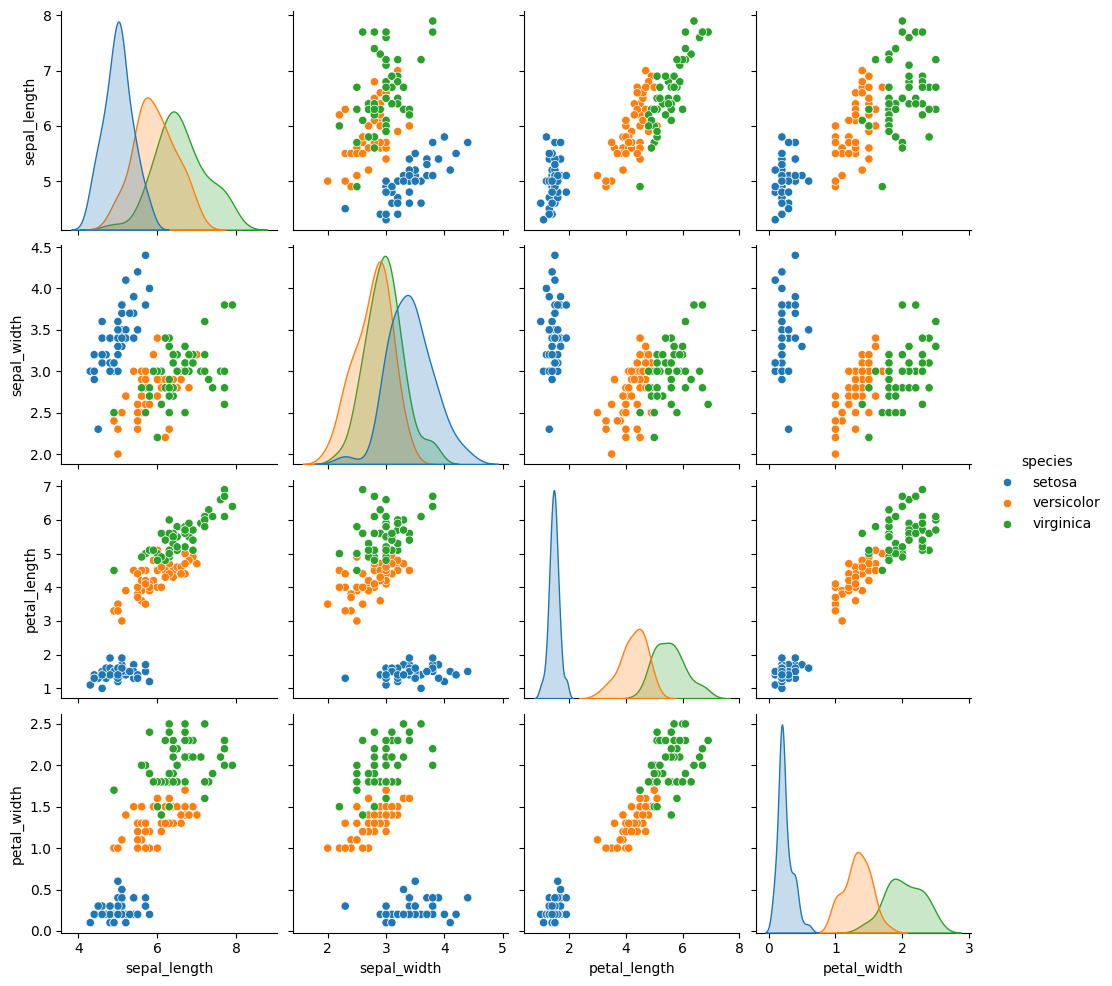

In [7]:
sns.pairplot(data=df,hue="species")
plt.show()

## 🖋 Class Encoding

In [8]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = df.iloc[:,-1] 
df["species"] = encoder.fit_transform(y=y)


## 🟢 Features Correlation

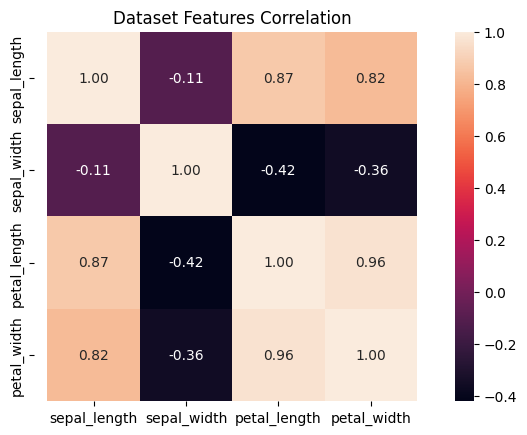

In [9]:
corr = df.iloc[:,:-1].corr(method="pearson")
sns.heatmap(data=corr,annot=True,fmt="0.2f",cbar=True)
plt.title("Dataset Features Correlation")
plt.axis("equal")
plt.show()

## 📍 Check Duplicates & Null Values

In [10]:
df.duplicated().sum()

np.int64(3)

In [11]:
df[df.duplicated()]

,sepal_length,sepal_width,petal_length,petal_width,species
34,4.9,3.1,1.5,0.1,0
37,4.9,3.1,1.5,0.1,0
142,5.8,2.7,5.1,1.9,2


In [12]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

## ✅ Model Build

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import accuracy_score ,f1_score , confusion_matrix , classification_report

In [14]:
X = df.loc[:,df.columns[:-1]]
Y = df.iloc[: , -1]

In [15]:
x_train , x_test, y_train , y_test = train_test_split(X,Y,test_size=0.2,shuffle=True,random_state=42)

In [16]:
model = DecisionTreeClassifier(random_state=42,criterion="gini",min_samples_split=0.5)
model = model.fit(x_train,y_train)
y_predicted = model.predict(x_test)


## ✅ Model Achieve 96.7% Accurecy and F1-Score

In [17]:
acc = accuracy_score(y_true=y_test,y_pred=y_predicted)
print(f"Decision Tree Classifier Accurecy = {acc * 100:0.1f} %")

Decision Tree Classifier Accurecy = 96.7 %


In [18]:
acc = f1_score(y_true=y_test,y_pred=y_predicted,average="micro")
print(f"Decision Tree Classifier F1-Score = {acc * 100:0.1f} %")

Decision Tree Classifier F1-Score = 96.7 %


In [19]:
print(classification_report(y_true=y_test,y_pred=y_predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



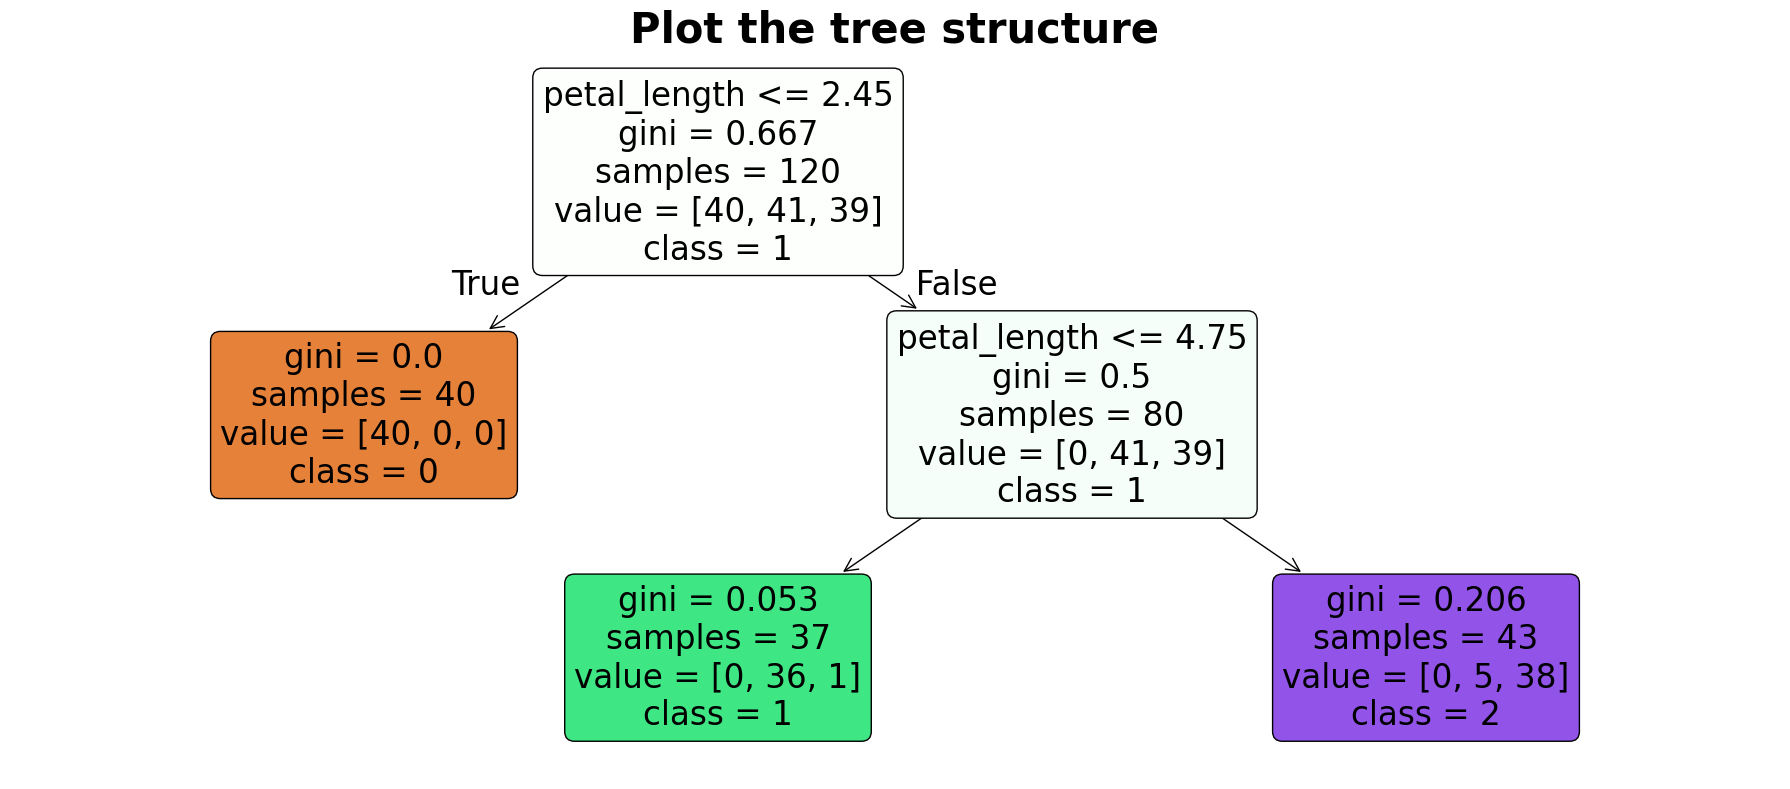

In [20]:
plt.figure(figsize=(18,8))
plot_tree(model, filled=True, feature_names=df.columns[:-1].tolist(), class_names=np.unique(df["species"]).astype(dtype=np.str_), rounded=True)
plt.title("Plot the tree structure",size=30,weight="bold")
plt.axis("equal")
plt.tight_layout()
plt.show()

## ✅ Features Importance

In [21]:
model_features = model.feature_names_in_.tolist()
features_importance = model.feature_importances_.tolist()

for feature , importance in zip(model_features,features_importance):
    print(f" '{feature}' Importance = {importance} ")

 'sepal_length' Importance = 0.0 
 'sepal_width' Importance = 0.0 
 'petal_length' Importance = 1.0 
 'petal_width' Importance = 0.0 


## ✅ Confusion Matrix

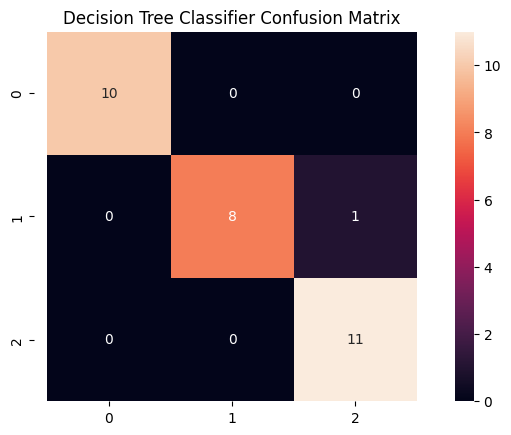

In [22]:
sns.heatmap(confusion_matrix(y_true=y_test,y_pred=y_predicted),annot=True)
plt.title("Decision Tree Classifier Confusion Matrix")
plt.axis("equal")
plt.show()

---

<h1 align="center">✅ The End of Task 5 </h1>

---
